Practice code to play with uproot and data stuff

## Set up for Data

In [1]:
# Import necessary libraries to start

import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

In [2]:
file_path = "root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root"
file = uproot.open(file_path)

In [3]:
file.keys()

['tag;1',
 'Events;1',
 'LuminosityBlocks;1',
 'Runs;1',
 'MetaData;1',
 'ParameterSets;1']

In [4]:
file.classnames()

{'tag;1': 'TObjString',
 'Events;1': 'TTree',
 'LuminosityBlocks;1': 'TTree',
 'Runs;1': 'TTree',
 'MetaData;1': 'TTree',
 'ParameterSets;1': 'TTree'}

In [5]:
t = file["Events"]
t.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
bunchCrossing        | uint32_t                 | AsDtype('>u4')
orbitNumber          | uint32_t                 | AsDtype('>u4')
HTXS_njets25         | uint8_t                  | AsDtype('uint8')
HTXS_njets30         | uint8_t                  | AsDtype('uint8')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDt

In [6]:
file["Events"].all_members

{'@fUniqueID': 0,
 '@fBits': 16777224,
 'fName': 'Events',
 'fTitle': 'Events',
 'fLineColor': 602,
 'fLineStyle': 1,
 'fLineWidth': 1,
 'fFillColor': 0,
 'fFillStyle': 1001,
 'fMarkerColor': 1,
 'fMarkerStyle': 1,
 'fMarkerSize': 1.0,
 'fEntries': 9999,
 'fTotBytes': 87703441,
 'fZipBytes': 19582442,
 'fSavedBytes': 0,
 'fFlushedBytes': 0,
 'fWeight': 1.0,
 'fTimerInterval': 0,
 'fScanField': 25,
 'fUpdate': 0,
 'fDefaultEntryOffsetLen': 1000,
 'fNClusterRange': 3,
 'fMaxEntries': 1000000000000,
 'fMaxEntryLoop': 1000000000000,
 'fMaxVirtualSize': 0,
 'fAutoSave': 0,
 'fAutoFlush': 0,
 'fEstimate': 1000000,
 'fClusterRangeEnd': array([ 999, 4375, 8751], dtype='>i8'),
 'fClusterSize': array([1000, 3376, 4376], dtype='>i8'),
 'fIOFeatures': <ROOT::TIOFeatures at 0x7f9ee01dd340>,
 'fBranches': <TObjArray of 2007 items at 0x7f9ee01b66f0>,
 'fLeaves': <TObjArray of 2007 items at 0x7f9ee01dea80>,
 'fAliases': None}

In [7]:
t["nMuon"].array()

<Array [3, 4, 3, 1, 5, 2, 2, 4, ..., 0, 3, 1, 1, 4, 3, 4] type='9999 * int32'>

In [8]:
t["Muon_pt"].array()

<Array [[297, 75, 30.7], ..., [77.6, ..., 3.57]] type='9999 * var * float32'>

In [9]:
t["nMuon"].array()

<Array [3, 4, 3, 1, 5, 2, 2, 4, ..., 0, 3, 1, 1, 4, 3, 4] type='9999 * int32'>

In [10]:
muons = t.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"]
)
muons

<Array [{Muon_pt: [...], ...}, ..., {...}] type='9999 * {Muon_pt: var * flo...'>

In [11]:
trigger = t["HLT_DoubleMu48NoFiltersNoVtx"].array(entry_stop=1000)

print(trigger)

[False, True, False, False, True, False, ..., False, True, False, False, False]


In [12]:
muons[trigger]

<Array [{Muon_pt: [...], ...}, ..., {...}] type='178 * {Muon_pt: var * floa...'>

In [13]:
muon_mask = (muons["Muon_pt"] >30)

print (muon_mask)

[[True, True, True], [True, True, ..., True], ..., [True, True, True, False]]


In [14]:
muon_mask[0:20].to_list()

[[True, True, True],
 [True, True, True, True],
 [True, True, False],
 [True],
 [True, True, True, False, False],
 [True, True],
 [True, False],
 [True, True, True, True],
 [True, True],
 [True, True, True],
 [True, True, True],
 [True, True, False],
 [True, True, False, False, False],
 [True, True, True],
 [True, False],
 [True, True, False, False],
 [True, True, True, True, True, False],
 [True, True, False],
 [True, True, False, False],
 [True, True, False]]

In [15]:
# We can apply muon_mask to the events "muons"
muons[muon_mask]

<Array [{Muon_pt: [...], ...}, ..., {...}] type='9999 * {Muon_pt: var * flo...'>

In [16]:
print(muons["Muon_mass"])

[[0.106, 0.106, 0.106], [0.106, ..., 0.106], ..., [0.106, 0.106, 0.106, 0.106]]


In [17]:
print(muons["Muon_charge"])

[[-1, -1, -1], [1, 1, 1, -1], [-1, -1, -1], ..., [-1, 1, -1], [1, 1, 1, 1]]


### Using ak for awkward arrays

In [18]:
>>> array = ak.Array([[[1.1, 2.2, 3.3],
...                    [],
...                    [4.4, 5.5],
...                    [6.6]
...                   ],
...                   [],
...                   [[7.7],
...                    [8.8, 9.9]]
...                   ])

In [19]:
ak.num(array, axis = 1)
#this will show the number of elements in the axis 1

<Array [4, 0, 2] type='3 * int64'>

In [20]:
ak.num(array, axis=2)

<Array [[3, 0, 2, 1], [], [1, 2]] type='3 * var * int64'>

In [21]:
ak.num(array, axis=0)
#the axis 0 will give a scalar that is the length of the array

array(3)

the array we created is a doubly nested array, this means thereis a list of lists, the length of the array in the 0 axis means there are three lists in the array, as we saw in the axis=1 command, the first list has 4 lists in it, the second has 0 and the last has 2. The axis=2 gives the number of elements for for each list inside each list.

In [22]:
array[ak.num(array) > 0, 0]

<Array [[1.1, 2.2, 3.3], [7.7]] type='2 * var * float64'>

In [23]:
array.mask[ak.num(array) > 0][:,0]

<Array [[1.1, 2.2, 3.3], None, [7.7]] type='3 * option[var * float64]'>

## Histograms

In [24]:
t["nMuon"].array()
#in order to refer to an object in the tree you need to type it like this
#the .array() makes it show up as an array and the "nMuon" is an object within the "t" tree

<Array [3, 4, 3, 1, 5, 2, 2, 4, ..., 0, 3, 1, 1, 4, 3, 4] type='9999 * int32'>

(array([2.780e+02, 1.497e+03, 3.343e+03, 3.040e+03, 1.448e+03, 3.220e+02,
        5.900e+01, 8.000e+00, 2.000e+00, 2.000e+00]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

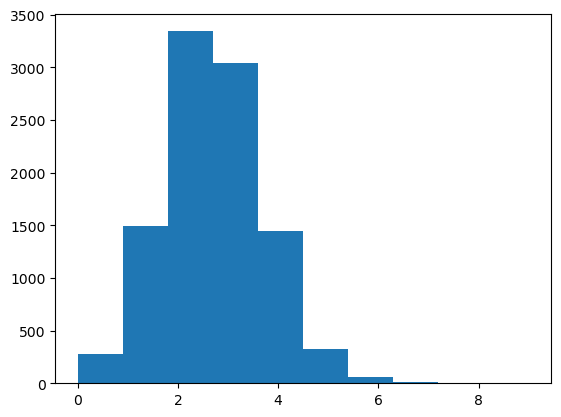

In [25]:
plt.hist(t["nMuon"].array())
#this plots a histogram of the nMuon array

In [26]:
Muon_pt = t["Muon_pt"].array()

In [27]:
Flat = ak.flatten(Muon_pt, axis=1)

In [28]:
Flat_pt = ak.flatten(Muon_pt, axis=None)

In [29]:
print(Flat_pt)

[297, 75, 30.7, 505, 180, 107, 88.1, ..., 201, 15.1, 77.6, 36.8, 30.4, 3.57]


(array([2.5147e+04, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([3.00182319e+00, 2.70268031e+05, 5.40533062e+05, 8.10798062e+05,
        1.08106312e+06, 1.35132812e+06, 1.62159312e+06, 1.89185812e+06,
        2.16212325e+06, 2.43238825e+06, 2.70265325e+06]),
 <BarContainer object of 10 artists>)

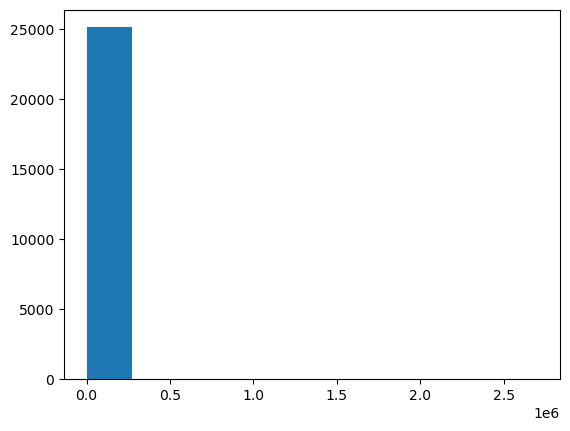

In [30]:
plt.hist(Flat_pt)

In [31]:
import boost_histogram as bh

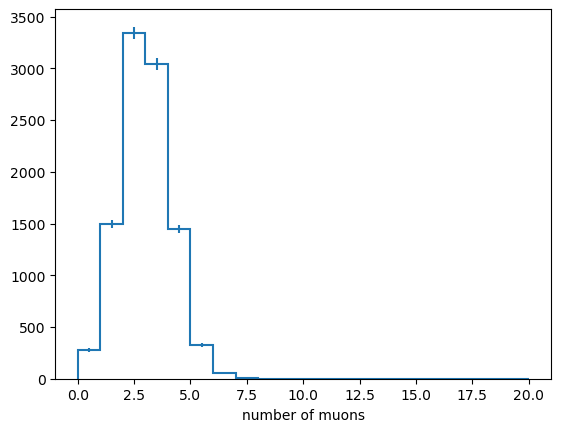

In [32]:
import hist

h = hist.Hist(hist.axis.Regular(20, 0, 20, name="number of muons"))

h.fill(t["nMuon"].array())

h.plot();

## Masks Investigation

In [33]:
# Let's start by looking at one of the masks from the Events TTree in the data file
# I just picked a random boolean array that started with HLT

print(t["HLT_EphemeralPhysics"].array())

[True, True, True, True, True, True, ..., True, True, True, True, True, True]


In [34]:
#Since the mask is longer than our data set (muons has 1000 entries) we need to slice the mask to match

mask1 = t["HLT_EphemeralPhysics"].array()[:1000]

In [35]:
print(mask1)

[True, True, True, True, True, True, ..., True, True, True, True, True, True]


In [36]:
#Now we can create an array where we apply the mask to the "muons" that we set as a variable earlier 

mask1_data = muons[mask1]

In [37]:
print(mask1_data)

[{Muon_pt: [297, 75, 30.7], Muon_eta: [0.431, ...], Muon_phi: [...], ...}, ...]


In [38]:
mask2 = t["HLT_DoubleL2Mu50"].array()[:1000]

In [39]:
print(mask2)

[True, True, False, True, True, True, ..., False, True, True, True, False]


In [40]:
mask2_data = muons[mask2]

print(mask2_data)

[{Muon_pt: [297, 75, 30.7], Muon_eta: [0.431, ...], Muon_phi: [...], ...}, ...]


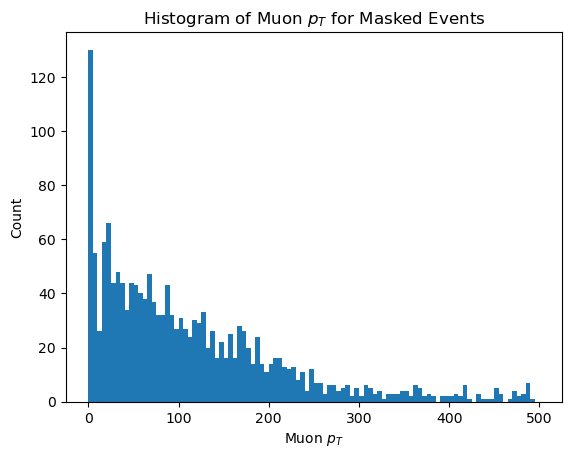

In [41]:
# To make a plot we cannot directly use plt.hist on the mask2_data because it is a jagged array

# First we will select the specific numerical field we want to plot (e.g., 'Muon_pt')
muon_pt_jagged = mask2_data["Muon_pt"]

# Then we can flatten the jagged data into a single 1D array of all muon pT values using the ak.flatten function
flat_muon_pt = ak.flatten(muon_pt_jagged, axis=None)

# Then plot the flattened data
plt.hist(flat_muon_pt, bins=100, range=(0,500))
plt.title('Histogram of Muon $p_T$ for Masked Events')
plt.xlabel('Muon $p_T$')
plt.ylabel('Count')
plt.show()

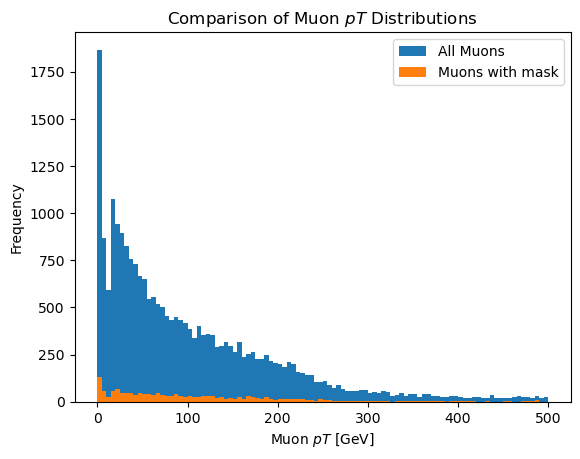

In [42]:
#This would be more useful with both histograms plotted together of with and without the mask

# Muon_pt without the mask
plt.hist(Flat_pt, bins=100, range=(0,500), label='All Muons')

# Muon_pt with the mask
plt.hist(flat_muon_pt, bins=100, range=(0,500), label='Muons with mask')

# We can add some titles and make sure the legend is displayed with more plt. functions
# For any text, we can add $ on either side to make it italicized
plt.legend(loc='upper right')

plt.title('Comparison of Muon $pT$ Distributions')
plt.xlabel('Muon $pT$ [GeV]')
plt.ylabel('Frequency')

plt.show()


(array([[1.867e+03, 8.690e+02, 5.940e+02, 1.074e+03, 9.410e+02, 8.950e+02,
         8.260e+02, 7.570e+02, 7.290e+02, 6.660e+02, 6.500e+02, 5.430e+02,
         5.560e+02, 5.180e+02, 5.050e+02, 4.540e+02, 4.330e+02, 4.500e+02,
         4.320e+02, 4.150e+02, 3.840e+02, 3.370e+02, 4.020e+02, 3.530e+02,
         3.570e+02, 3.530e+02, 2.900e+02, 2.970e+02, 3.150e+02, 2.930e+02,
         2.630e+02, 3.170e+02, 2.360e+02, 2.550e+02, 2.620e+02, 2.240e+02,
         2.270e+02, 2.490e+02, 2.180e+02, 2.070e+02, 2.000e+02, 1.830e+02,
         2.100e+02, 1.980e+02, 1.590e+02, 1.520e+02, 1.410e+02, 1.420e+02,
         1.020e+02, 1.050e+02, 1.110e+02, 8.700e+01, 7.200e+01, 9.000e+01,
         6.600e+01, 5.700e+01, 5.600e+01, 5.700e+01, 6.300e+01, 6.300e+01,
         4.600e+01, 5.200e+01, 4.600e+01, 5.700e+01, 4.900e+01, 3.200e+01,
         3.700e+01, 4.400e+01, 3.300e+01, 4.200e+01, 4.000e+01, 2.600e+01,
         4.300e+01, 4.100e+01, 3.000e+01, 2.900e+01, 2.600e+01, 2.600e+01,
         3.200e+01, 3.100

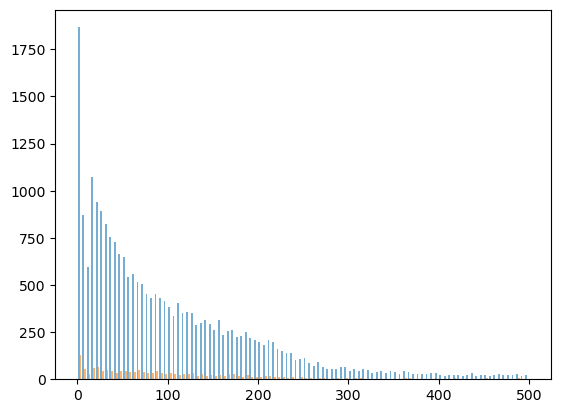

In [43]:
# This would be even better if we could get both in the same graph

plt.hist(x=[Flat_pt, flat_muon_pt], alpha=0.6, bins=100, range=(0,500))

Let's apply more than one mask to the muons array

In [44]:
# We're going to create and apply two makss that pick out all muons with over 30GeV pt and less than 2.4 eta

# We already defined Muon_pt but we should also define Muon_eta

Muon_eta = t["Muon_eta"].array()

# Now to create the masks

pt_condition = Muon_pt > 30
eta_condition = Muon_eta < 2.4 

combined_muon_mask = pt_condition & eta_condition

#Since we are applying the masks to an awkward array not just a simple set of numbers, we need to use ak.any()

event_mask = ak.any(combined_muon_mask, axis=1)

# Finally we can apply the event_mask and we get the filtered events

filtered_events = muons[event_mask]

print(filtered_events.show())


[{Muon_pt: [297, 75, 30.7], Muon_eta: [0.431, ..., 0.31], Muon_phi: [...], ...},
 {Muon_pt: [505, 180, 107, 88.1], Muon_eta: [0.504, ...], Muon_phi: [...], ...},
 {Muon_pt: [191, 172, 26.9], Muon_eta: [1.33, ..., 1.47], Muon_phi: [...], ...},
 {Muon_pt: [35.8], Muon_eta: [-0.397], Muon_phi: [-3.14], Muon_mass: ..., ...},
 {Muon_pt: [285, 54.4, ..., 16.5, 4.53], Muon_eta: [1.7, ...], ...},
 {Muon_pt: [189, 68.5], Muon_eta: [0.72, -0.451], Muon_phi: [...], ...},
 {Muon_pt: [119, 3.28], Muon_eta: [-0.719, ...], Muon_phi: [...], ...},
 {Muon_pt: [159, 79.5, 61, 33.8], Muon_eta: [0.545, ...], Muon_phi: [...], ...},
 {Muon_pt: [259, 104], Muon_eta: [-0.302, ...], Muon_phi: [...], ...},
 {Muon_pt: [174, 138, 34.2], Muon_eta: [0.323, ...], Muon_phi: [...], ...},
 ...,
 {Muon_pt: [477, 57.3], Muon_eta: [0.92, -1.72], Muon_phi: [...], ...},
 {Muon_pt: [180, 17, 6.36], Muon_eta: [-1.53, ...], Muon_phi: [...], ...},
 {Muon_pt: [159, 106], Muon_eta: [0.653, 0.686], Muon_phi: [...], ...},
 {Muon_pt:

In [45]:
# Let's seee if we can do this again but with different conditions that are double-ended

pt_lower_bound = Muon_pt > 30.0
pt_upper_bound = Muon_pt < 1000.0
pt_condition2 = pt_lower_bound & pt_upper_bound

eta_lower_bound = Muon_eta > -2.4
eta_upper_bound = Muon_eta < 2.4
eta_condition2 = eta_lower_bound & eta_upper_bound

combined_muon_mask2 = pt_condition & eta_condition

event_mask2 = ak.any(combined_muon_mask2, axis=1)

filtered_events2 = muons[event_mask2]

print(filtered_events2.show())



[{Muon_pt: [297, 75, 30.7], Muon_eta: [0.431, ..., 0.31], Muon_phi: [...], ...},
 {Muon_pt: [505, 180, 107, 88.1], Muon_eta: [0.504, ...], Muon_phi: [...], ...},
 {Muon_pt: [191, 172, 26.9], Muon_eta: [1.33, ..., 1.47], Muon_phi: [...], ...},
 {Muon_pt: [35.8], Muon_eta: [-0.397], Muon_phi: [-3.14], Muon_mass: ..., ...},
 {Muon_pt: [285, 54.4, ..., 16.5, 4.53], Muon_eta: [1.7, ...], ...},
 {Muon_pt: [189, 68.5], Muon_eta: [0.72, -0.451], Muon_phi: [...], ...},
 {Muon_pt: [119, 3.28], Muon_eta: [-0.719, ...], Muon_phi: [...], ...},
 {Muon_pt: [159, 79.5, 61, 33.8], Muon_eta: [0.545, ...], Muon_phi: [...], ...},
 {Muon_pt: [259, 104], Muon_eta: [-0.302, ...], Muon_phi: [...], ...},
 {Muon_pt: [174, 138, 34.2], Muon_eta: [0.323, ...], Muon_phi: [...], ...},
 ...,
 {Muon_pt: [477, 57.3], Muon_eta: [0.92, -1.72], Muon_phi: [...], ...},
 {Muon_pt: [180, 17, 6.36], Muon_eta: [-1.53, ...], Muon_phi: [...], ...},
 {Muon_pt: [159, 106], Muon_eta: [0.653, 0.686], Muon_phi: [...], ...},
 {Muon_pt:

### For Loop to check triggers

In [46]:
# Now we're going to create a for loop that checks how many events pass each trigger 

# Recall that we have "muons" to refer to all the muon events, and Muon_pt and Muon_eta defined already
# First we need to isolate the names of the triggers we want to analyze

# Let's just start with the original file

file_path = "root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root"
file = uproot.open(file_path)

#We'll define the Events object in the file

Events = file["Events"]

# then we want to use the .keys() to create a list of all the branch names in "Events" 
# We showed all the names and their attributes earlier in the code but here we want just a simple list of the names only so its easy to see

all_branch_names = list(Events.keys())

# Check that it worked using the print function
print(all_branch_names)


['run', 'luminosityBlock', 'event', 'bunchCrossing', 'orbitNumber', 'HTXS_njets25', 'HTXS_njets30', 'HTXS_stage1_1_cat_pTjet25GeV', 'HTXS_stage1_1_cat_pTjet30GeV', 'HTXS_stage1_1_fine_cat_pTjet25GeV', 'HTXS_stage1_1_fine_cat_pTjet30GeV', 'HTXS_stage1_2_cat_pTjet25GeV', 'HTXS_stage1_2_cat_pTjet30GeV', 'HTXS_stage1_2_fine_cat_pTjet25GeV', 'HTXS_stage1_2_fine_cat_pTjet30GeV', 'HTXS_stage_0', 'HTXS_stage_1_pTjet25', 'HTXS_stage_1_pTjet30', 'HTXS_Higgs_pt', 'HTXS_Higgs_y', 'HTXS_Mjj', 'HTXS_V_pt', 'HTXS_dPhijj', 'HTXS_ptHjj', 'BeamSpot_type', 'BeamSpot_sigmaZ', 'BeamSpot_sigmaZError', 'BeamSpot_z', 'BeamSpot_zError', 'nboostedTau', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'b

In [47]:
# Now we can make a simple for loop to print only the first dozen items that start with "HLT_" 
# this gives us a list of names we can use when we want to analyze triggers later

hlt_triggers = []
for name in all_branch_names:
    if name.startswith("HLT_"):
        hlt_triggers.append(name)

print(hlt_triggers[:40])

# This is mostly so I don't have to keep scrolling back up to the beginning of the notebook and then scroll through the list of 
# items in events to find the HLT stuff. I'm slicing it at 20 but if I wanted to see more or different ones we could change the slicing
# i.e. 20:40 to see the next 20 triggers that start with HLT

['HLT_EphemeralPhysics', 'HLT_EphemeralZeroBias', 'HLT_EcalCalibration', 'HLT_HcalCalibration', 'HLT_HcalNZS', 'HLT_HcalPhiSym', 'HLT_Random', 'HLT_Physics', 'HLT_ZeroBias', 'HLT_ZeroBias_Alignment', 'HLT_ZeroBias_Beamspot', 'HLT_ZeroBias_IsolatedBunches', 'HLT_ZeroBias_FirstBXAfterTrain', 'HLT_ZeroBias_FirstCollisionAfterAbortGap', 'HLT_ZeroBias_FirstCollisionInTrain', 'HLT_ZeroBias_LastCollisionInTrain', 'HLT_HT300_Beamspot', 'HLT_IsoTrackHB', 'HLT_IsoTrackHE', 'HLT_PFJet40_GPUvsCPU', 'HLT_AK8PFJet380_SoftDropMass30', 'HLT_AK8PFJet400_SoftDropMass30', 'HLT_AK8PFJet425_SoftDropMass30', 'HLT_AK8PFJet450_SoftDropMass30', 'HLT_AK8DiPFJet250_250_SoftDropMass40', 'HLT_AK8DiPFJet250_250_SoftDropMass50', 'HLT_AK8DiPFJet260_260_SoftDropMass30', 'HLT_AK8DiPFJet260_260_SoftDropMass40', 'HLT_AK8DiPFJet270_270_SoftDropMass30', 'HLT_AK8DiPFJet280_280_SoftDropMass30', 'HLT_AK8DiPFJet290_290_SoftDropMass30', 'HLT_CaloJet500_NoJetID', 'HLT_CaloJet550_NoJetID', 'HLT_DoubleMu5_Upsilon_DoubleEle3_CaloId

In [48]:
# We now have a list of triggers we want to analyze, lets make a for loop to analyze them

N_EVENTS = Events.num_entries # Get the total number of events
 
# Analyze Triggers (This is the main loop where we'll get the number of events passed for each trigger)

# first we'll define the array of results, we'll add entries to this as we apply the masks and get pass numbers
# Try an or for the HLT triggers (group them together) like the DoubleMu ones 

analysis_results = []

# Since we already created a list
for name in hlt_triggers: 
    mask_array = Events[name].array()
    # The .items() function allows us to use the dictionary we set up so that each iteration of the for loop we can look at both
    # the name and the value, "for name" references the "HLT_..." part of the dictionary that is the names of the triggers. The
    # "mask_array" part refers to the dictionary value which is the actual data mask array
   
    passed_count = np.sum(mask_array)
    # the function numpy.sum() treats True as 1 and False as 0 
    # this means for passed_count, np.sum simply adds up all the 1s (the True values), giving you the total events that passed
    
    # Calculate the percentage of events that pass the trigger 
    # this is an easy math function, we don't necessarily need it but it could be useful to see
    pass_percentage = (passed_count / N_EVENTS) * 100
    
    # Store the results by appending them to the analysis results array
    # In the array we want to store multiple things for each item (like how in "muons" each muon has different variables stored)
    # To do this we use another dictionary where there is a name, count, and percent, for which we store different values
    analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results

# Sort the results in descending order based on 'count'
# To do this we can use the pyhton sorted() function to create a new sorted list that doesn't modify the original list
# the key part tells python what to sort it by, we use lambda x: x["count"] to tell it to look at the count value for sorting
# reverse=True makes the new list sorted from largest values to smallest

sorted_results = sorted(analysis_results, key=lambda x: x["count"], reverse=True)

# To make the output easy to read we can add in a title and make it into a table

print(f"TRIGGER ANALYSIS REPORT (Total Events = {N_EVENTS})")  # title line
print("-" * 85)                                                # separate the title with a bunch of dashes

print(f"{'Trigger Name':<50} | {'Events Passed':>15} | {'Pass Rate':>12}")  # make 3 columns for the trigger, number events, and pass rate
print("-" * 85)

# In the print function, : introduces format specifier, the < indicates left alignment > is right, and the 30 means 30 characters
# this way all the different rows of the table we make will be in nice columns that are aligned

# then we can print the results using another for loop
# in this one we just need to say that for each item in the "sorted_results" array we want to print the name string and the count and percent numbers

for result in sorted_results[:30]:
    print(
        f"{result['name']:<50} | "
        f"{result['count']:>15,} | "  # Use comma for thousands separator
        f"{result['percent']:>12.2f}%"
    )


TRIGGER ANALYSIS REPORT (Total Events = 9999)
-------------------------------------------------------------------------------------
Trigger Name                                       |   Events Passed |    Pass Rate
-------------------------------------------------------------------------------------
HLT_EphemeralPhysics                               |           9,999 |       100.00%
HLT_EphemeralZeroBias                              |           9,999 |       100.00%
HLT_EcalCalibration                                |           9,999 |       100.00%
HLT_HcalCalibration                                |           9,999 |       100.00%
HLT_HcalNZS                                        |           9,999 |       100.00%
HLT_Random                                         |           9,999 |       100.00%
HLT_Physics                                        |           9,999 |       100.00%
HLT_ZeroBias                                       |           9,999 |       100.00%
HLT_ZeroBias_Align

In [49]:
#Since it looks like a lot of the initial ones are just 100 percent pass rate, I'm going to try to 
# get a list of all the HLT_Mu triggers because they are more likely to have varying pass rates.

mu_hlt_triggers = []
for name in all_branch_names:
    if name.startswith("HLT_") and "DoubleL2Mu" in name:
        mu_hlt_triggers.append(name)

print(mu_hlt_triggers[:30])

['HLT_DoubleL2Mu30NoVtx_2Cha_CosmicSeed_Eta2p4', 'HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4', 'HLT_DoubleL2Mu50', 'HLT_DoubleL2Mu23NoVtx_2Cha_CosmicSeed', 'HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed', 'HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4', 'HLT_DoubleL2Mu23NoVtx_2Cha', 'HLT_DoubleL2Mu25NoVtx_2Cha', 'HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4', 'HLT_DoubleL2Mu10NoVtx_2Cha_VetoL3Mu0DxyMax1cm', 'HLT_DoubleL2Mu12NoVtx_2Cha_VetoL3Mu0DxyMax1cm', 'HLT_DoubleL2Mu14NoVtx_2Cha_VetoL3Mu0DxyMax1cm', 'HLT_DoubleL2Mu_L3Mu16NoVtx_VetoL3Mu0DxyMax0p1cm', 'HLT_DoubleL2Mu_L3Mu18NoVtx_VetoL3Mu0DxyMax0p1cm', 'HLT_DoubleL2Mu10NoVtx_2Cha_CosmicSeed_VetoL3Mu0DxyMax1cm', 'HLT_DoubleL2Mu12NoVtx_2Cha_CosmicSeed_VetoL3Mu0DxyMax1cm']


In [50]:
# Now lets run the same code with the HLT_Mu triggers

N_EVENTS = Events.num_entries # Get the total number of events

# Analyze Triggers 

analysis_results = []

for name in mu_hlt_triggers: 
    mask_array = Events[name].array()

    # Count the number of events that pass 
    passed_count = np.sum(mask_array)
    
    # Calculate the percentage of events that pass the trigger 
    pass_percentage = (passed_count / N_EVENTS) * 100
    
    # Store the results by appending them to the analysis results array
    analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results

sorted_results = sorted(analysis_results, key=lambda x: x["count"], reverse=True)

# Make table

print(f"TRIGGER ANALYSIS REPORT (Total Events = {N_EVENTS})")  # title line
print("-" * 84)                                            # separate the title with a bunch of dashes

print(f"{'Trigger Name':<57} | {'Events Passed':>12}| {'Pass Rate':>10}")  # make 3 columns 
print("-" * 84)

# Print the results
for result in sorted_results:
    print(
        f"{result['name']:<57} | "
        f"{result['count']:>12,} | "  
        f"{result['percent']:>8.2f}%"
    )


TRIGGER ANALYSIS REPORT (Total Events = 9999)
------------------------------------------------------------------------------------
Trigger Name                                              | Events Passed|  Pass Rate
------------------------------------------------------------------------------------
HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4                         |        7,381 |    73.82%
HLT_DoubleL2Mu23NoVtx_2Cha                                |        7,246 |    72.47%
HLT_DoubleL2Mu25NoVtx_2Cha                                |        7,143 |    71.44%
HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4                         |        7,138 |    71.39%
HLT_DoubleL2Mu50                                          |        6,332 |    63.33%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4              |        5,579 |    55.80%
HLT_DoubleL2Mu23NoVtx_2Cha_CosmicSeed                     |        5,562 |    55.63%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed                     |        5,422 |    54.23%
HLT_DoubleL2Mu30No

In [51]:
# Just to double check that this is correct I'm going to separately apply one of the masks to muons and see if
# it returns the right number of muon events. The smallest count is 4 so I'll use that one since it should be easy to check

HLT_Mu27_mask = Events["HLT_Mu27_Ele37_CaloIdL_MW"].array()

mask_applied = muons[HLT_Mu27_mask]

# We applied the mask, now we just need to get the number of muons from the result
# For this use the ak.num() function and set the axis to 0 since we want the total muons and don't really care about the pt and eta numbers 

ak.num(mask_applied, axis=0)

array(4)

The ak.num confirmed that the mask gives us 4 events that pass which means our code worked!

In [52]:
# Now I want to repeat the same thing but create my own masks and then hopefully get a list of how many events pass
# for varying levels of pt or some other variable (we can start with pt since it is most familiar)

#create masks the way we did before, we'll do muons with pt greater than 30 and greater than 50

N_MUONS = ak.sum(ak.num(Muon_pt))   # Use ak. function to get the actual number of muons not just number of events

pt_gt_30_mask = Muon_pt > 30
pt_gt_50_mask = Muon_pt > 50

# Convert the muon-level mask to an event-level mask using ak.any(axis=1)
# This checks if ANY muon in the event satisfies the condition.

conditions = {
    "Event_Has_Muon_pt_gt_30": ak.any(pt_gt_30_mask, axis=1),
    "Event_Has_Muon_pt_gt_50": ak.any(pt_gt_50_mask, axis=1),
}

# The for loop to analyze the results of the mask is the same as before

analysis_results = []

for name, mask_array in conditions.items():

    # Count the number of events that pass 
    passed_count = ak.sum(mask_array, axis=None)
    
    # Calculate the percentage of events that pass the trigger 
    pass_percentage = (passed_count / N_MUONS) * 100
    
    # Store the results by appending them to the analysis results array
    analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results

sorted_results = sorted(analysis_results, key=lambda x: x["count"], reverse=True)

# Make table

print(f"MUON CONDITION ANALYSIS REPORT (Total Muons = {N_MUONS})")  # title line
print("-" * 65)                                            # separate the title with a bunch of dashes

print(f"{'Condition':<30} | {'Muons Passed':>15} | {'Pass Rate':>10}")  # make 3 columns 
print("-" * 65)


# Print the results
for result in sorted_results:
    print(
        f"{result['name']:<30} | "
        f"{result['count']:>15,} | "  
        f"{result['percent']:>8.2f} %"
    )

MUON CONDITION ANALYSIS REPORT (Total Muons = 25149)
-----------------------------------------------------------------
Condition                      |    Muons Passed |  Pass Rate
-----------------------------------------------------------------
Event_Has_Muon_pt_gt_30        |           9,237 |    36.73 %
Event_Has_Muon_pt_gt_50        |           8,815 |    35.05 %


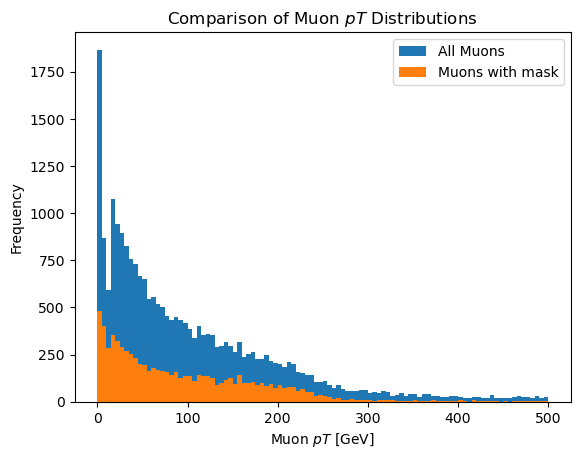

In [53]:
# Now lets apply multiple masks from the library in Events

# Muon_pt without the mask
# Flat_pt was defined previously for another histogram so we don't have to redefine it (this is with no mask)

plt.hist(Flat_pt, bins=100, range=(0,500), label='All Muons')

# Define triggers (these will be event level and select whole events from the muons array 

HLT_Mu4_L1DoubleMu = Events["HLT_Mu4_L1DoubleMu"].array()
HLT_Mu0_L1DoubleMu = Events["HLT_Mu0_L1DoubleMu"].array()

# Combine the triggers to get a combined mask
combined_mask = HLT_Mu4_L1DoubleMu & HLT_Mu0_L1DoubleMu

# Muon_pt with the masks applied
filtered_events = muons[combined_mask]

# Extract the specific variable (Muon_pt) from the filtered events (this gets rid of the other variable for this histogram
# but we could also get another variable for the same mask if we wanted)
muon_pt_jagged = filtered_events["Muon_pt"]

# Flatten the jagged Muon_pt array for histogram plotting
flat_muon_pt = ak.flatten(muon_pt_jagged, axis=None)

plt.hist(flat_muon_pt, bins=100, range=(0,500), label='Muons with mask')

# We can add some titles and make sure the legend is displayed with more plt. functions
# For any text, we can add $ on either side to make it italicized
plt.legend(loc='upper right')

plt.title('Comparison of Muon $pT$ Distributions')
plt.xlabel('Muon $pT$ [GeV]')
plt.ylabel('Frequency')

plt.show()


In [54]:
print(muons)

[{Muon_pt: [297, 75, 30.7], Muon_eta: [0.431, ...], Muon_phi: [...], ...}, ...]


## Ratio of Histograms Plot

In [71]:
import uproot
import vector
import hist
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from sidm.tools import utilities
# could not import sidm_processor because it depends on the cutflow file that contains "processor.AccumulatorABC" that is not a coffea attribute

import mplhep as hep
plt.style.use(hep.style.CMS)

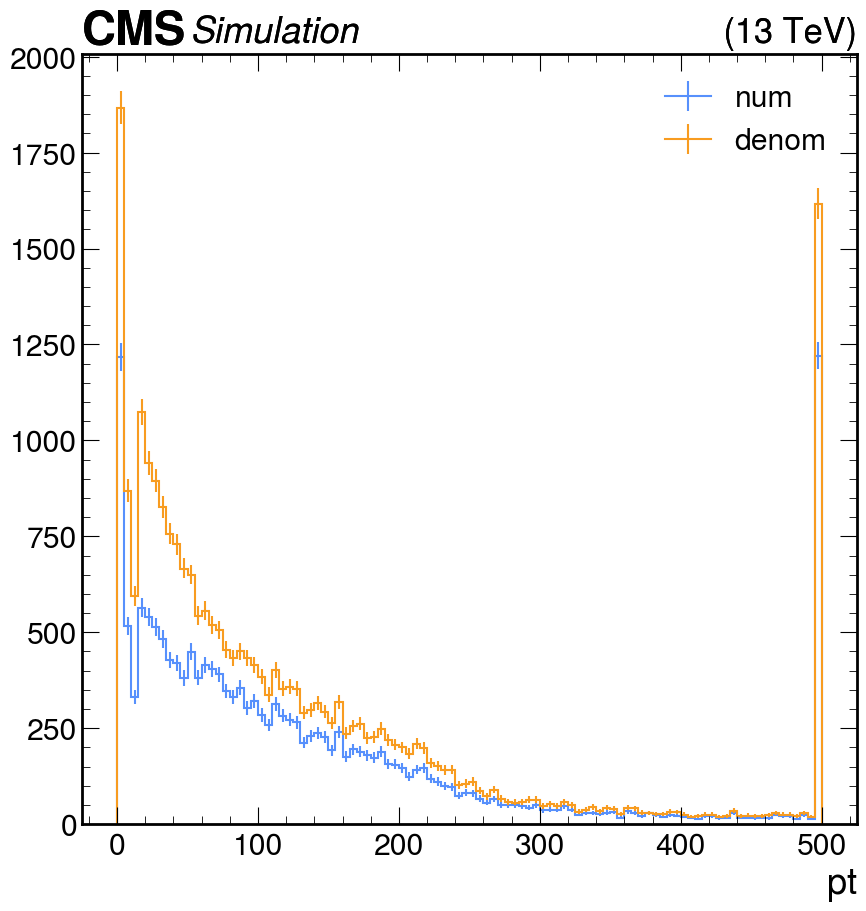

In [68]:
# Now lets try making a histogram using some of the masks we have seen before:

# first define the two masks we will use

HLT_DoubleL2Mu50 = Events["HLT_DoubleL2Mu50"].array()   # In the table made previously this had a 63.33% pass rate
HLT_DoubleL2Mu25NoVtx_2Cha = Events["HLT_DoubleL2Mu25NoVtx_2Cha"].array()   # this trigger has a 71.44% pass rate

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt[HLT_DoubleL2Mu50]))
denominator.fill(ak.flatten(Muon_pt))

#Plot both on the same figure
utilities.plot(numerator, label = "num")
utilities.plot(denominator, label ="denom")
plt.legend(loc = 'upper right')

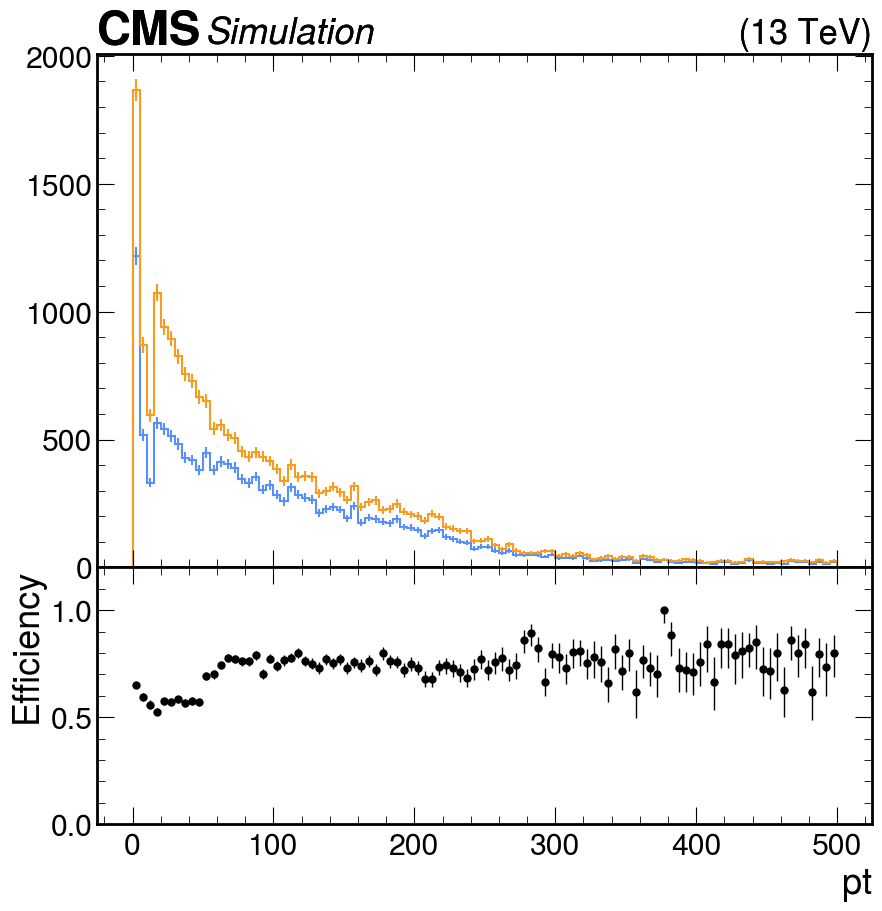

In [70]:
#Plot both along with their ratio. The warnings occur if there are any bins with zero counts and can be safely ignored. 
#If the numerator is ever greater than the denominator in any bin, this will throw an error
utilities.plot_ratio(numerator,denominator)

# Try to add lines on to graph (like a grid so it's easier to see)